In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [134]:
%matplotlib inline 

In [136]:
gen1=pd.read_csv('Plant_1_Generation_Data.csv')
gen2=pd.read_csv('Plant_2_Generation_Data.csv')

# تولید برق — نیروگاه ۱
# تولید برق — نیروگاه 2

In [68]:
Wea1=pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
Wea2=pd.read_csv('Plant_2_Weather_Sensor_Data.csv')
# آب‌وهوا — نیروگاه 1
# آب‌وهوا — نیروگاه 2

In [137]:
gen1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [70]:
gen2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    67698 non-null  object 
 1   PLANT_ID     67698 non-null  int64  
 2   SOURCE_KEY   67698 non-null  object 
 3   DC_POWER     67698 non-null  float64
 4   AC_POWER     67698 non-null  float64
 5   DAILY_YIELD  67698 non-null  float64
 6   TOTAL_YIELD  67698 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.6+ MB


ستون‌های Generation:

DC_POWER — برق DC (مستقیم از پنل‌ها)

AC_POWER — برق AC (بعد از اینورتر، قابل استفاده)

DAILY_YIELD — تولید روزانه

TOTAL_YIELD — تولید کل تا الان

In [138]:
Wea1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[ns]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           3182 non-null   object        
 3   AMBIENT_TEMPERATURE  3182 non-null   float64       
 4   MODULE_TEMPERATURE   3182 non-null   float64       
 5   IRRADIATION          3182 non-null   float64       
 6   date                 3182 non-null   object        
 7   hour                 3182 non-null   int32         
 8   day                  3182 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(2)
memory usage: 199.0+ KB


In [139]:
Wea2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3259 non-null   datetime64[ns]
 1   PLANT_ID             3259 non-null   int64         
 2   SOURCE_KEY           3259 non-null   object        
 3   AMBIENT_TEMPERATURE  3259 non-null   float64       
 4   MODULE_TEMPERATURE   3259 non-null   float64       
 5   IRRADIATION          3259 non-null   float64       
 6   date                 3259 non-null   object        
 7   hour                 3259 non-null   int32         
 8   day                  3259 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(2)
memory usage: 203.8+ KB


ستون‌های Weather:


AMBIENT_TEMPERATURE — دمای محیط

MODULE_TEMPERATURE — دمای پنل خورشیدی

IRRADIATION — شدت تابش خورشید


In [140]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-darkgrid')

In [141]:
print(f"✅ Plant 1 Generation: {gen1.shape[0]:,} ردیف | {gen1.shape[1]} ستون")
print(f"✅ Plant 1 Weather:    {Wea1.shape[0]:,} ردیف | {Wea1.shape[1]} ستون")
print(f"✅ Plant 2 Generation: {gen2.shape[0]:,} ردیف | {gen2.shape[1]} ستون")
print(f"✅ Plant 2 Weather:    {Wea2.shape[0]:,} ردیف | {Wea2.shape[1]} ستون")

✅ Plant 1 Generation: 68,778 ردیف | 7 ستون
✅ Plant 1 Weather:    3,182 ردیف | 9 ستون
✅ Plant 2 Generation: 67,698 ردیف | 7 ستون
✅ Plant 2 Weather:    3,259 ردیف | 9 ستون


In [142]:
print(Wea1.isnull().sum())
print('...................')
print(Wea2.isnull().sum())
print('.............')
print(gen1.isnull().sum())
print('-------------')
print(gen2.isnull().sum())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
date                   0
hour                   0
day                    0
dtype: int64
...................
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
date                   0
hour                   0
day                    0
dtype: int64
.............
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
-------------
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


data cleaning

In [143]:
for df in [gen1, Wea1, gen2, Wea2]:
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True)

C:\Users\GIGALAP.IR\AppData\Local\Temp\ipykernel_17996\3691575139.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], dayfirst=True)


In [144]:
print('DATE_TIME','too datatime')

DATE_TIME too datatime


In [145]:
print(f"{gen1['DATE_TIME'].iloc[100]}")
print(f"{gen1['DATE_TIME'].dtype}")

2020-05-15 01:00:00
datetime64[ns]


In [146]:
# --- Fix DC scale mismatch (Plant 1) ---
gen1['DC_POWER_CORR'] = gen1['DC_POWER'] / 10
gen2['DC_POWER_CORR'] = gen2['DC_POWER']


In [147]:
for df in [gen1, Wea1, gen2, Wea2]:
        df['date']  = df['DATE_TIME'].dt.date   # فقط تاریخ
        df['hour']  = df['DATE_TIME'].dt.hour   # فقط ساعت
        df['day']   = df['DATE_TIME'].dt.day    # روز ماه
    


In [148]:
print("\n✅ ستون‌های کمکی اضافه شدند: date, hour, day")


✅ ستون‌های کمکی اضافه شدند: date, hour, day


In [82]:
print(f"   Plant 1: {gen1['DATE_TIME'].min().date()} too {gen1['DATE_TIME'].max().date()}")

   Plant 1: 2020-05-15 too 2020-06-17


In [83]:
print(f"  Plant 2: {gen2['DATE_TIME'].min().date()} too {gen2['DATE_TIME'].max().date()}")

  Plant 2: 2020-05-15 too 2020-06-17


In [149]:
# ادغام داده تولید و آب‌وهوا برای Plant 1
wea1_hourly = Wea1.groupby('DATE_TIME').agg({
    'IRRADIATION': 'mean',
    'AMBIENT_TEMPERATURE': 'mean',
    'MODULE_TEMPERATURE': 'mean'
}).reset_index()

gen1_hourly = gen1.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()

merged1 = pd.merge(gen1_hourly, wea1_hourly, on='DATE_TIME')
merged1 = merged1[merged1['AC_POWER'] > 0]  # فقط وقتی تولید هست

print(f"✅ merged1 آماده شد: {merged1.shape[0]} ردیف")
print(merged1.head(3))

✅ merged1 آماده شد: 1687 ردیف
             DATE_TIME     AC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  \
24 2020-05-15 06:00:00    90.929167     0.005887            24.088446   
25 2020-05-15 06:15:00   593.338690     0.022282            24.011635   
26 2020-05-15 06:30:00  1480.194643     0.049410            23.976731   

    MODULE_TEMPERATURE  
24           22.206757  
25           22.353459  
26           22.893282  


describe

In [150]:
print("\n" + "=" * 60)
print("📊 describ.............. Plant 1 Generation")
print("=" * 60)


📊 describ.............. Plant 1 Generation


In [151]:
 
stats = gen1[['DC_POWER', 'AC_POWER', 'DAILY_YIELD']].describe().round(2)


In [87]:
stats

,DC_POWER,AC_POWER,DAILY_YIELD
count,68778.00,68778.00,68778.00
mean,3147.43,307.80,3295.97
std,4036.46,394.40,3145.18
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,429.00,41.49,2658.71
75%,6366.96,623.62,6274.00
max,14471.12,1410.95,9163.00


In [88]:
print(stats.to_string())

       DC_POWER  AC_POWER  DAILY_YIELD
count  68778.00  68778.00     68778.00
mean    3147.43    307.80      3295.97
std     4036.46    394.40      3145.18
min        0.00      0.00         0.00
25%        0.00      0.00         0.00
50%      429.00     41.49      2658.71
75%     6366.96    623.62      6274.00
max    14471.12   1410.95      9163.00


In [152]:
print("\n---Comparison of Two Power Plants---")
print(f" Mean' AC_POWER  | Plant 1: {gen1['AC_POWER'].mean():>10.2f} kW")
print(f"                  | Plant 2: {gen2['AC_POWER'].mean():>10.2f} kW")
print(f" Max AC_POWER   | Plant 1: {gen1['AC_POWER'].max():>10.2f} kW")
print(f"                  | Plant 2: {gen2['AC_POWER'].max():>10.2f} kW")


---Comparison of Two Power Plants---
 Mean' AC_POWER  | Plant 1:     307.80 kW
                  | Plant 2:     241.28 kW
 Max AC_POWER   | Plant 1:    1410.95 kW
                  | Plant 2:    1385.42 kW


Visuall

تجسم داده — نمودارها

نمودار ۱: تولید روزانه AC — مقایسه دو نیروگاه

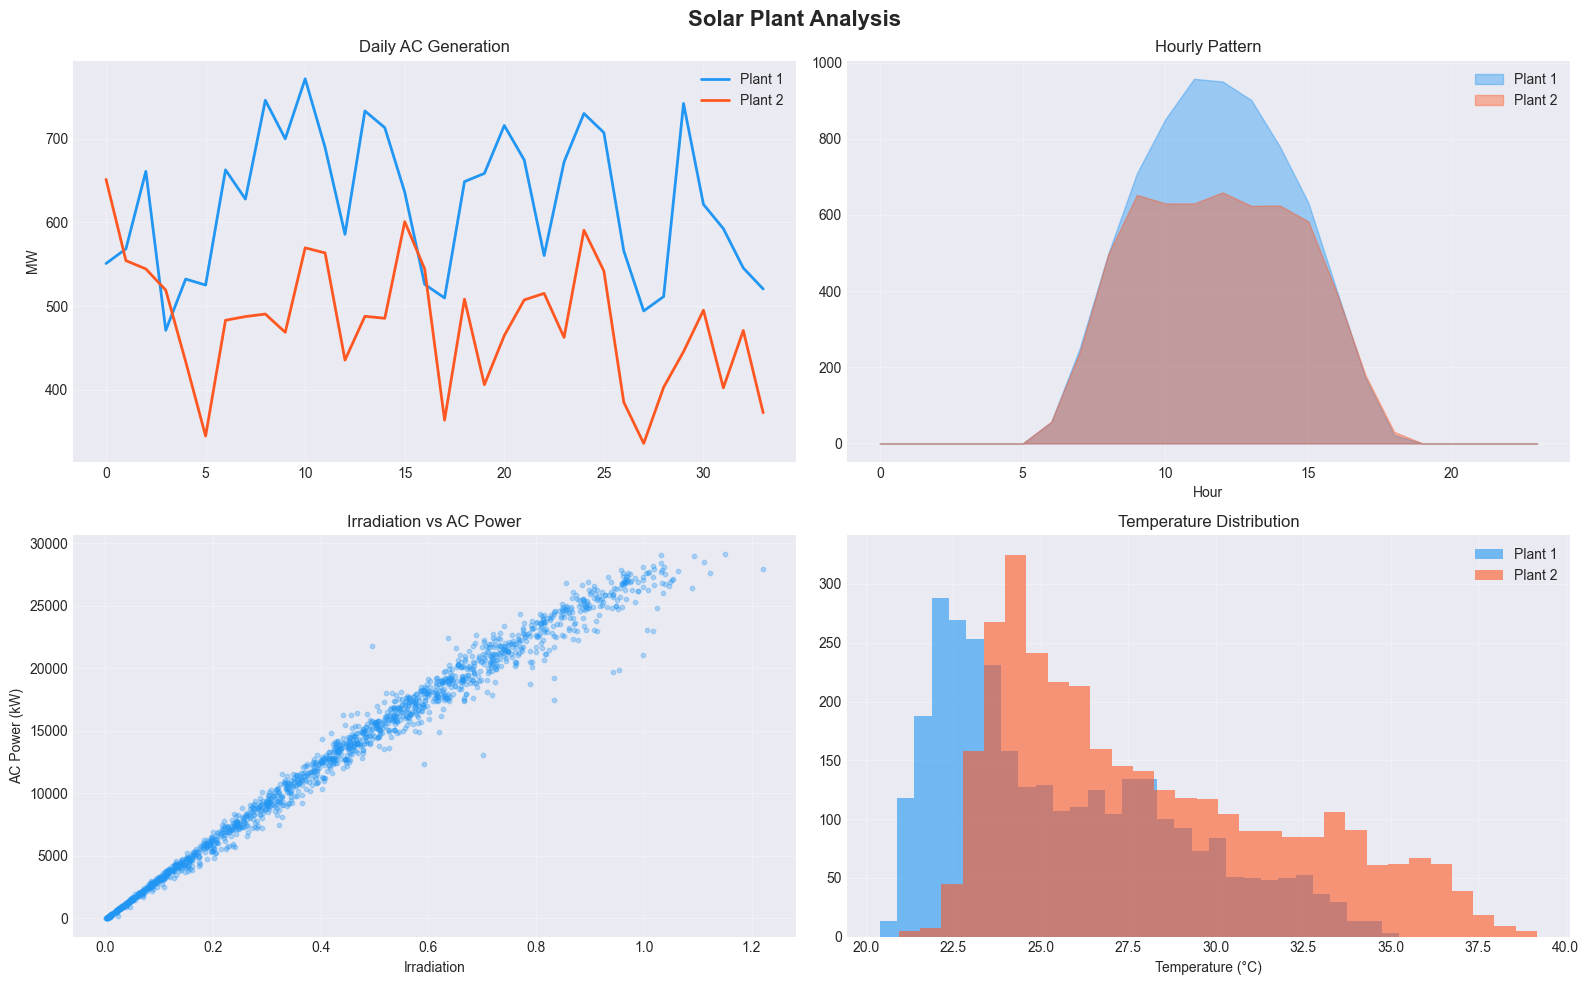

In [153]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solar Plant Analysis', fontsize=16, fontweight='bold')

# نمودار ۱ — تولید روزانه
ax1 = axes[0, 0]
daily1 = gen1.groupby('date')['AC_POWER'].sum() / 1000
daily2 = gen2.groupby('date')['AC_POWER'].sum() / 1000
ax1.plot(range(len(daily1)), daily1.values, label='Plant 1', color='#2196F3', linewidth=2)
ax1.plot(range(len(daily2)), daily2.values, label='Plant 2', color='#FF5722', linewidth=2)
ax1.set_title('Daily AC Generation')
ax1.set_ylabel('MW')
ax1.legend()

# نمودار ۲ — الگوی ساعتی
ax2 = axes[0, 1]
hourly1 = gen1.groupby('hour')['AC_POWER'].mean()
hourly2 = gen2.groupby('hour')['AC_POWER'].mean()
ax2.fill_between(hourly1.index, hourly1.values, alpha=0.4, color='#2196F3', label='Plant 1')
ax2.fill_between(hourly2.index, hourly2.values, alpha=0.4, color='#FF5722', label='Plant 2')
ax2.set_title('Hourly Pattern')
ax2.set_xlabel('Hour')
ax2.legend()

# نمودار ۳ — scatter تابش
ax3 = axes[1, 0]
ax3.scatter(merged1['IRRADIATION'], merged1['AC_POWER'], alpha=0.3, s=10, color='#2196F3')
ax3.set_title('Irradiation vs AC Power')
ax3.set_xlabel('Irradiation')
ax3.set_ylabel('AC Power (kW)')

# نمودار ۴ — توزیع دما
ax4 = axes[1, 1]
ax4.hist(Wea1['AMBIENT_TEMPERATURE'], bins=30, alpha=0.6, color='#2196F3', label='Plant 1')
ax4.hist(Wea2['AMBIENT_TEMPERATURE'], bins=30, alpha=0.6, color='#FF5722', label='Plant 2')
ax4.set_title('Temperature Distribution')
ax4.set_xlabel('Temperature (°C)')
ax4.legend()

plt.tight_layout()
plt.show()


---------------------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------------------

Plant 1 هم در تولید روزانه و هم در الگوی ساعتی معمولاً بهتر از Plant 2 دیده می‌شود.
رابطه‌ی تابش و توان کاملاً مشخص و منطقی است.

Plant 2 دماهای بالاتری دارد که می‌تواند یکی از علت‌های تولید کمتر باشد (البته قطعی نیست، ولی محتمل است).


In [91]:
# اضافه کردن ستون day_of_week
gen1['day_of_week'] = gen1['DATE_TIME'].dt.day_name()
gen2['day_of_week'] = gen2['DATE_TIME'].dt.day_name()

# تست
print(gen1['day_of_week'].unique())

['Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday']


C:\Users\GIGALAP.IR\AppData\Local\Temp\ipykernel_17996\74107828.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_box, labels=labels_box, patch_artist=True)


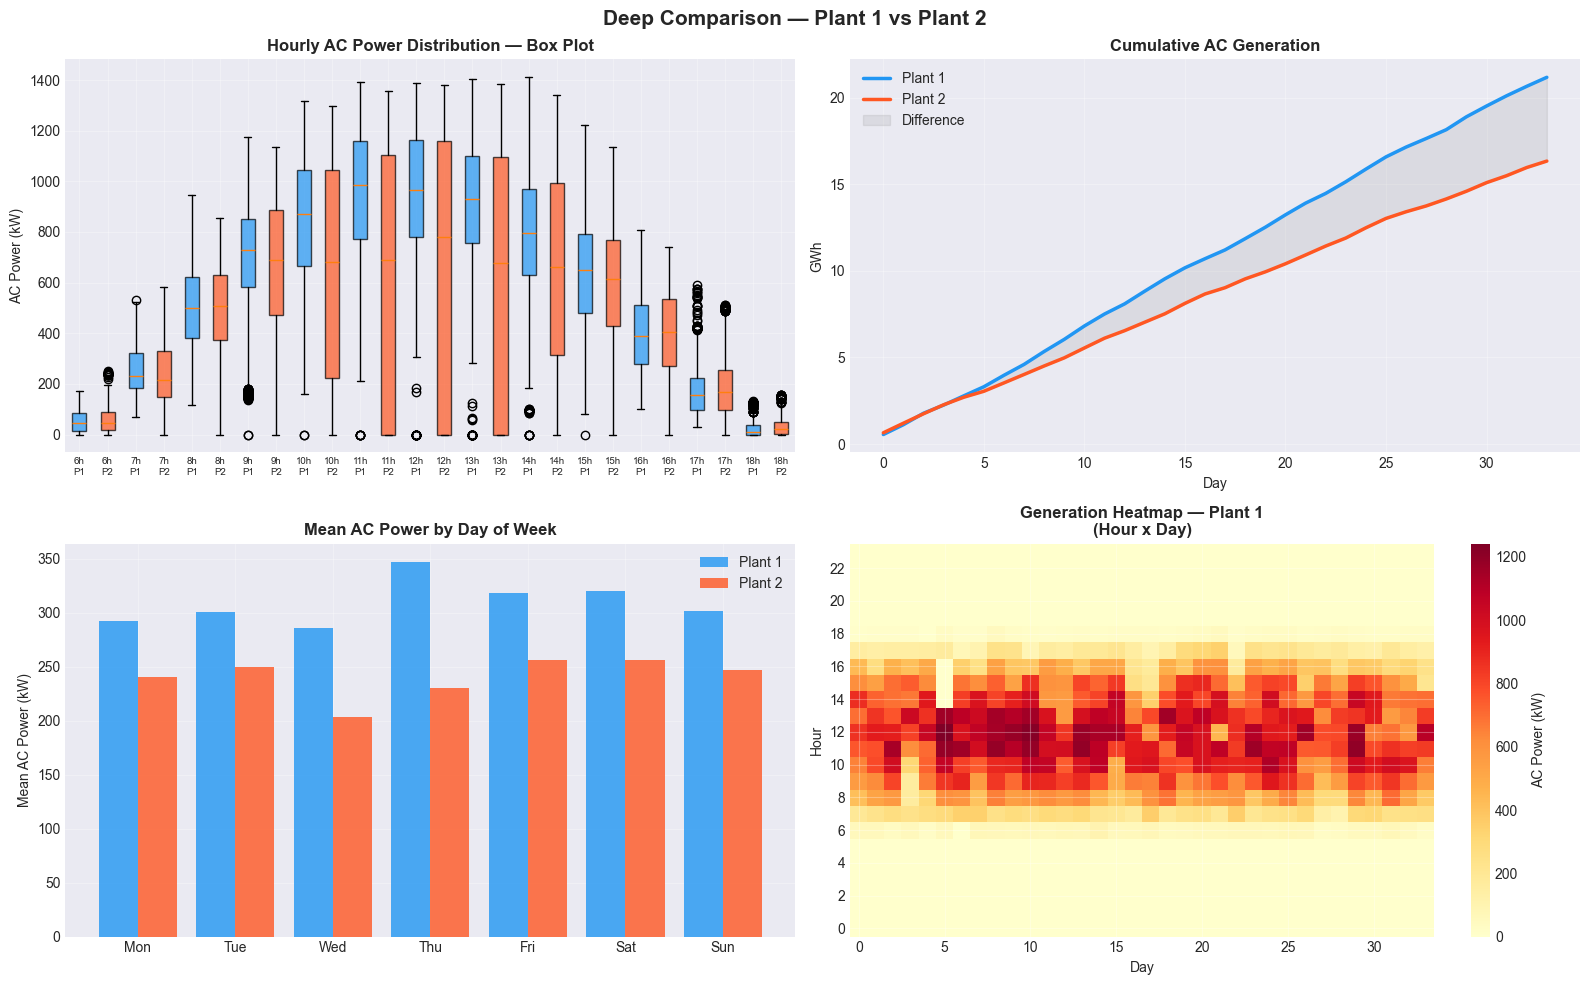

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Chart 1: Box Plot - Hourly Generation Distribution ──
ax1 = axes[0, 0]
data_box = []
labels_box = []
for hour in range(6, 19):
    d1 = gen1[gen1['hour'] == hour]['AC_POWER'].values
    d2 = gen2[gen2['hour'] == hour]['AC_POWER'].values
    data_box.extend([d1, d2])
    labels_box.extend([f'{hour}h\nP1', f'{hour}h\nP2'])

bp = ax1.boxplot(data_box, labels=labels_box, patch_artist=True)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#2196F3' if i % 2 == 0 else '#FF5722')
    patch.set_alpha(0.7)
ax1.set_title('Hourly AC Power Distribution — Box Plot', fontweight='bold')
ax1.set_ylabel('AC Power (kW)')
ax1.tick_params(axis='x', labelsize=7)

# ── Chart 2: Cumulative Generation ──
ax2 = axes[0, 1]
daily1 = gen1.groupby('date')['AC_POWER'].sum().cumsum() / 1e6
daily2 = gen2.groupby('date')['AC_POWER'].sum().cumsum() / 1e6
ax2.plot(range(len(daily1)), daily1.values, color='#2196F3', linewidth=2.5, label='Plant 1')
ax2.plot(range(len(daily2)), daily2.values, color='#FF5722', linewidth=2.5, label='Plant 2')
ax2.fill_between(range(len(daily1)), daily1.values, daily2.values,
                 alpha=0.15, color='gray', label='Difference')
ax2.set_title('Cumulative AC Generation', fontweight='bold')
ax2.set_xlabel('Day')
ax2.set_ylabel('GWh')
ax2.legend()

# ── Chart 3: Average Generation by Day of Week ──
ax3 = axes[1, 0]
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dw1 = gen1.groupby('day_of_week')['AC_POWER'].mean().reindex(order)
dw2 = gen2.groupby('day_of_week')['AC_POWER'].mean().reindex(order)
x = range(7)
ax3.bar([i - 0.2 for i in x], dw1.values, width=0.4, color='#2196F3', label='Plant 1', alpha=0.8)
ax3.bar([i + 0.2 for i in x], dw2.values, width=0.4, color='#FF5722', label='Plant 2', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax3.set_title('Mean AC Power by Day of Week', fontweight='bold')
ax3.set_ylabel('Mean AC Power (kW)')
ax3.legend()

# ── Chart 4: Heatmap — Hour x Day (Plant 1) ──
ax4 = axes[1, 1]
pivot = gen1.groupby(['date', 'hour'])['AC_POWER'].mean().unstack(fill_value=0)
im = ax4.imshow(pivot.values.T, aspect='auto', cmap='YlOrRd', origin='lower')
plt.colorbar(im, ax=ax4, label='AC Power (kW)')
ax4.set_title('Generation Heatmap — Plant 1\n(Hour x Day)', fontweight='bold')
ax4.set_xlabel('Day')
ax4.set_ylabel('Hour')
ax4.set_yticks(range(0, 24, 2))
ax4.set_yticklabels(range(0, 24, 2))

plt.suptitle('Deep Comparison — Plant 1 vs Plant 2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

-----------------------------------------------------

------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------

In [93]:
# تصحیح واحد DC_POWER برای Plant 1
gen1['DC_POWER_kW'] = gen1['DC_POWER'] / 1000

# حالا efficiency درست حساب می‌شه
working = gen1[gen1['DC_POWER_kW'] > 0].copy()
working['efficiency'] = working['AC_POWER'] / working['DC_POWER_kW']

by_inverter = working.groupby('SOURCE_KEY')['efficiency'].mean().sort_values()
print(f"Plant 1 efficiency after fix:")
print(f"  Min: {by_inverter.min():.4f}")
print(f"  Max: {by_inverter.max():.4f}")
print(f"  Mean: {by_inverter.mean():.4f}")

Plant 1 efficiency after fix:
  Min: 97.7106
  Max: 97.7333
  Mean: 97.7189


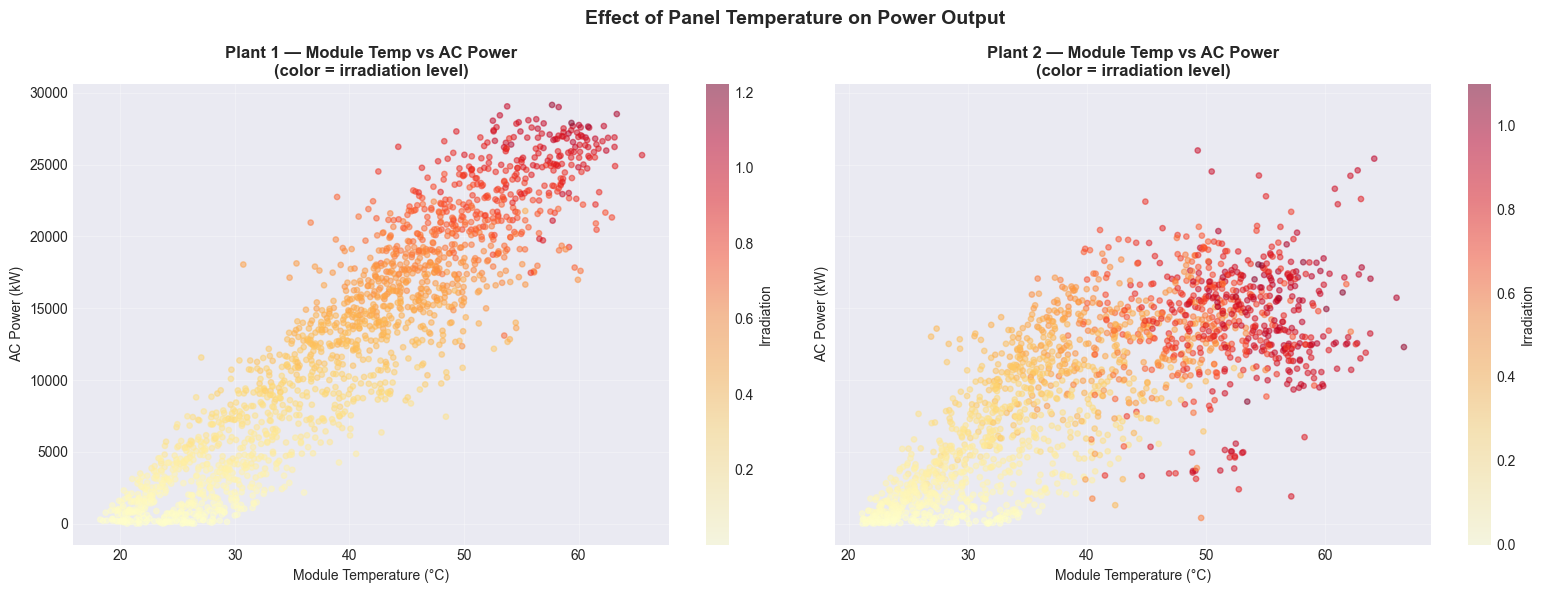


Correlation Matrix — Plant 1:
                     AC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE
AC_POWER                1.000        0.992                0.537               0.924
IRRADIATION             0.992        1.000                0.537               0.928
AMBIENT_TEMPERATURE     0.537        0.537                1.000               0.755
MODULE_TEMPERATURE      0.924        0.928                0.755               1.000

Correlation Matrix — Plant 2:
                     AC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE
AC_POWER                1.000        0.831                0.482               0.764
IRRADIATION             0.831        1.000                0.534               0.913
AMBIENT_TEMPERATURE     0.482        0.534                1.000               0.792
MODULE_TEMPERATURE      0.764        0.913                0.792               1.000


In [94]:
wea1_h = Wea1.groupby('DATE_TIME')[['IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']].mean().reset_index()
wea2_h = Wea2.groupby('DATE_TIME')[['IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']].mean().reset_index()

gen1_h = gen1.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()
gen2_h = gen2.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()

m1 = pd.merge(gen1_h, wea1_h, on='DATE_TIME', how='inner')
m2 = pd.merge(gen2_h, wea2_h, on='DATE_TIME', how='inner')

m1 = m1[m1['AC_POWER'] > 0]
m2 = m2[m2['AC_POWER'] > 0]

# ── Scatter plot: Module Temperature vs AC Power ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, merged, name in zip(axes, [m1, m2], ['Plant 1', 'Plant 2']):
    sc = ax.scatter(
        merged['MODULE_TEMPERATURE'],
        merged['AC_POWER'],
        c=merged['IRRADIATION'],
        cmap='YlOrRd',
        alpha=0.5,
        s=15
    )
    plt.colorbar(sc, ax=ax, label='Irradiation')
    ax.set_title(f'{name} — Module Temp vs AC Power\n(color = irradiation level)', fontweight='bold')
    ax.set_xlabel('Module Temperature (°C)')
    ax.set_ylabel('AC Power (kW)')

plt.suptitle('Effect of Panel Temperature on Power Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Correlation Matrix ──
cols = ['AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

print("\nCorrelation Matrix — Plant 1:")
print(m1[cols].corr().round(3).to_string())

print("\nCorrelation Matrix — Plant 2:")
print(m2[cols].corr().round(3).to_string())


Plant 1 خیلی منظم‌تره — نقاط تقریباً یه خط مستقیم تشکیل می‌دن، یعنی رابطه خیلی قوی بین دما و تولیده.


Plant 2 پراکنده‌تره — همون دما، تولیدهای مختلف داره. این می‌تونه نشانه مشکل در بعضی اینورترها باشه!

In [95]:
print("\n" + "=" * 60)
print("📋 Final Summary")
print("=" * 60)

total1 = gen1.groupby('date')['AC_POWER'].sum().mean() / 1e3
total2 = gen2.groupby('date')['AC_POWER'].sum().mean() / 1e3

print(f"\n🌞 Average Daily Generation:")
print(f"   Plant 1: {total1:.2f} MWh/day")
print(f"   Plant 2: {total2:.2f} MWh/day")
print(f"   Ratio:   Plant 2 / Plant 1 = {total2/total1:.2f}x")

print(f"\n🌡️ Average Weather Conditions:")
print(f"   Plant 1 | Temp: {Wea1['AMBIENT_TEMPERATURE'].mean():.1f}°C | Irradiation: {Wea1['IRRADIATION'].mean():.4f}")
print(f"   Plant 2 | Temp: {Wea2['AMBIENT_TEMPERATURE'].mean():.1f}°C | Irradiation: {Wea2['IRRADIATION'].mean():.4f}")



📋 Final Summary

🌞 Average Daily Generation:
   Plant 1: 622.65 MWh/day
   Plant 2: 480.41 MWh/day
   Ratio:   Plant 2 / Plant 1 = 0.77x

🌡️ Average Weather Conditions:
   Plant 1 | Temp: 25.5°C | Irradiation: 0.2283
   Plant 2 | Temp: 28.1°C | Irradiation: 0.2327


📊 تحلیل نتایج Final Summary:
تولید:

Plant 1 روزانه 622 MWh تولید می‌کنه
Plant 2 فقط 480 MWh — یعنی 23% کمتر!

جالب اینجاست:

Plant 2 تابش بیشتری داره (0.2327 vs 0.2283)
Plant 2 دمای بیشتری داره (28.1°C vs 25.5°C)

نتیجه‌گیری مهم برای پروژه:

با اینکه Plant 2 آفتاب بیشتری دریافت می‌کنه، ولی 23% کمتر تولید داره — این احتمالاً به خاطر دمای بالاتر پنل‌هاست که راندمان رو کاهش می‌ده، یا اینورترهای معیوب!

In [96]:
# خلاصه نهایی → Final Summary
# متوسط تولید روزانه → Average Daily Generation
# نسبت → Ratio
# متوسط شرایط جوی → Average Weather Conditions
# دما → Temp
# تابش → Irradiation

In [97]:
# 🎓 آموزش: گزارش نهایی با f-string و قالب‌بندی

daily1 = gen1.groupby('date')['AC_POWER'].sum() / 1000
daily2 = gen2.groupby('date')['AC_POWER'].sum() / 1000

print("=" * 55)
print("       📊 خلاصه نهایی EDA — Solar Plants")
print("=" * 55)
print(f"\n{'متریک':<30} {'Plant 1':>10} {'Plant 2':>10}")
print("-" * 55)
print(f"{'تعداد اینورتر':<30} {'22':>10} {'22':>10}")
print(f"{'متوسط تولید روزانه (MWh)':<30} {daily1.mean():>10.1f} {daily2.mean():>10.1f}")
print(f"{'بیشینه تولید روزانه (MWh)':<30} {daily1.max():>10.1f} {daily2.max():>10.1f}")
print(f"{'کمینه تولید روزانه (MWh)':<30} {daily1.min():>10.1f} {daily2.min():>10.1f}")
print(f"{'کل تولید دوره (GWh)':<30} {daily1.sum()/1000:>10.2f} {daily2.sum()/1000:>10.2f}")
print(f"{'متوسط دمای محیط (°C)':<30} {Wea1['AMBIENT_TEMPERATURE'].mean():>10.1f} {Wea2['AMBIENT_TEMPERATURE'].mean():>10.1f}")
print(f"{'متوسط تابش':<30} {Wea1['IRRADIATION'].mean():>10.4f} {Wea2['IRRADIATION'].mean():>10.4f}")
print("=" * 55)
print("\n✅ EDA کامل شد! مرحله بعد: Anomaly Detection 🚀")

       📊 خلاصه نهایی EDA — Solar Plants

متریک                             Plant 1    Plant 2
-------------------------------------------------------
تعداد اینورتر                          22         22
متوسط تولید روزانه (MWh)            622.6      480.4
بیشینه تولید روزانه (MWh)           771.6      651.4
کمینه تولید روزانه (MWh)            471.0      335.8
کل تولید دوره (GWh)                 21.17      16.33
متوسط دمای محیط (°C)                 25.5       28.1
متوسط تابش                         0.2283     0.2327

✅ EDA کامل شد! مرحله بعد: Anomaly Detection 🚀


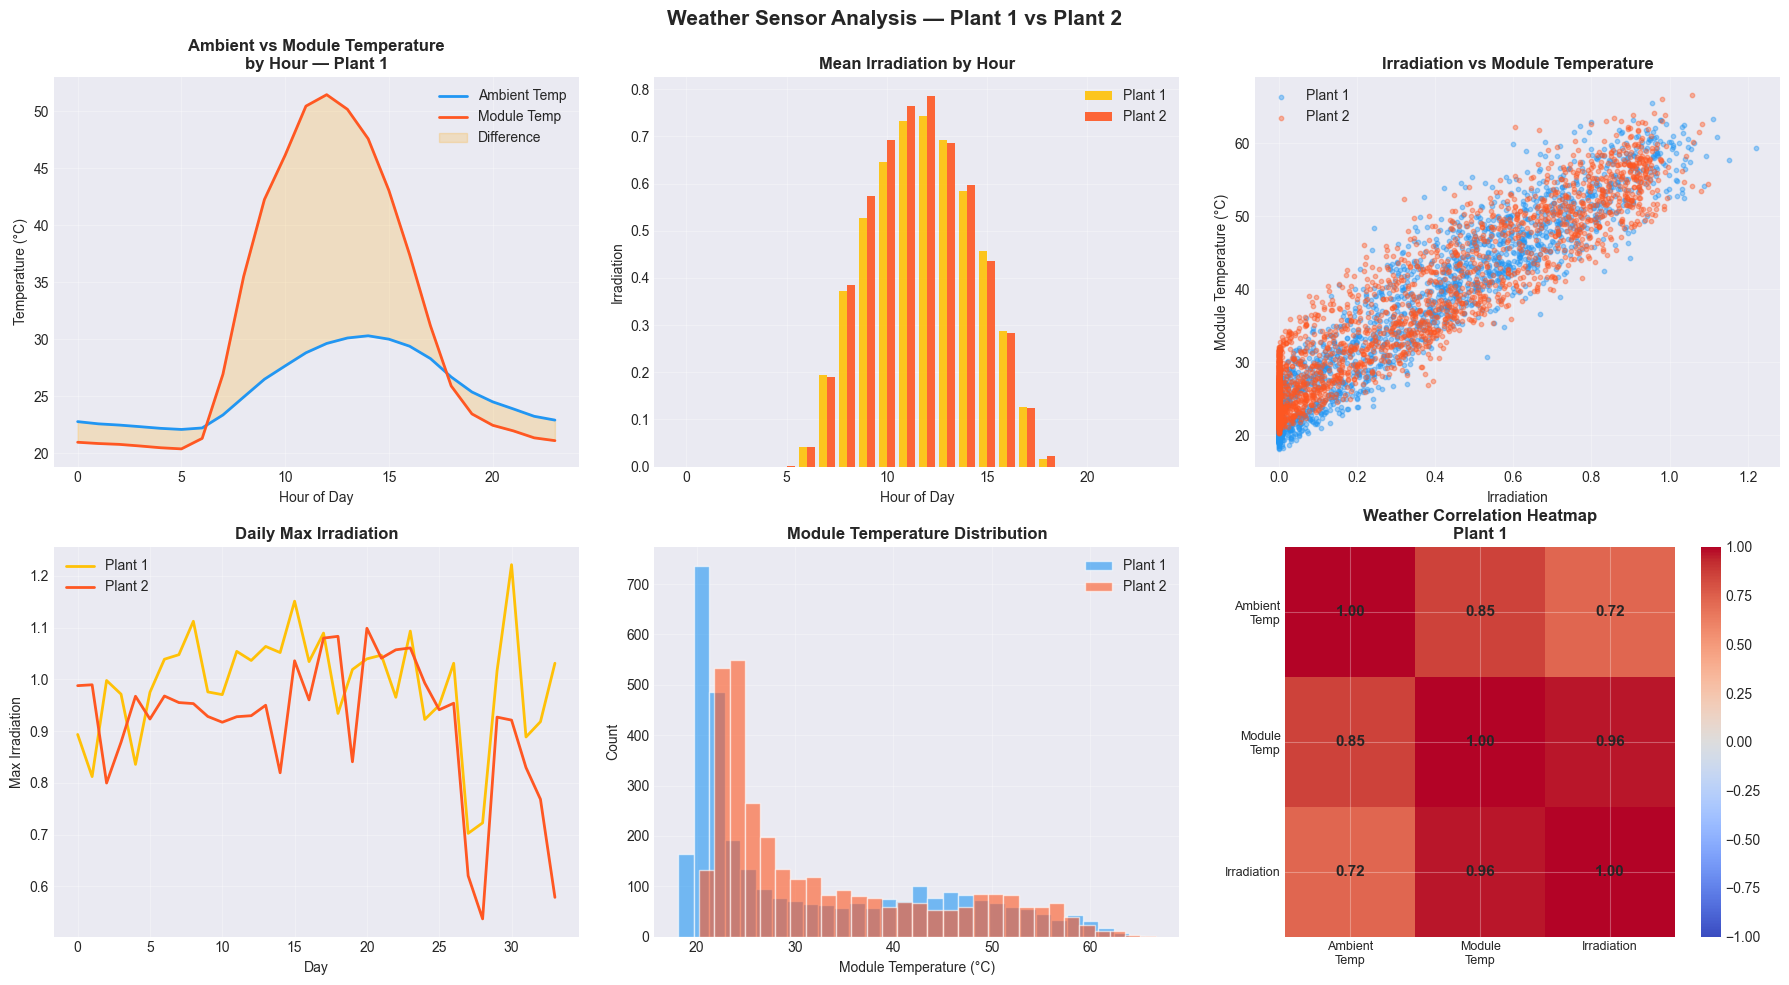

In [98]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Chart 1: Average Temperature by Hour ──
ax1 = axes[0, 0]
amb1 = Wea1.groupby('hour')['AMBIENT_TEMPERATURE'].mean()
mod1 = Wea1.groupby('hour')['MODULE_TEMPERATURE'].mean()
ax1.plot(amb1.index, amb1.values, color='#2196F3', linewidth=2, label='Ambient Temp')
ax1.plot(mod1.index, mod1.values, color='#FF5722', linewidth=2, label='Module Temp')
ax1.fill_between(mod1.index, amb1.values, mod1.values, alpha=0.2, color='orange', label='Difference')
ax1.set_title('Ambient vs Module Temperature\nby Hour — Plant 1', fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()

# ── Chart 2: Irradiation by Hour ──
ax2 = axes[0, 1]
irr1 = Wea1.groupby('hour')['IRRADIATION'].mean()
irr2 = Wea2.groupby('hour')['IRRADIATION'].mean()
ax2.bar(irr1.index - 0.2, irr1.values, width=0.4, color='#FFC107', label='Plant 1', alpha=0.9)
ax2.bar(irr2.index + 0.2, irr2.values, width=0.4, color='#FF5722', label='Plant 2', alpha=0.9)
ax2.set_title('Mean Irradiation by Hour', fontweight='bold')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Irradiation')
ax2.legend()

# ── Chart 3: Module Temp vs Irradiation Scatter ──
ax3 = axes[0, 2]
ax3.scatter(Wea1['IRRADIATION'], Wea1['MODULE_TEMPERATURE'],
            alpha=0.4, s=10, color='#2196F3', label='Plant 1')
ax3.scatter(Wea2['IRRADIATION'], Wea2['MODULE_TEMPERATURE'],
            alpha=0.4, s=10, color='#FF5722', label='Plant 2')
ax3.set_title('Irradiation vs Module Temperature', fontweight='bold')
ax3.set_xlabel('Irradiation')
ax3.set_ylabel('Module Temperature (°C)')
ax3.legend()

# ── Chart 4: Daily Max Irradiation ──
ax4 = axes[1, 0]
daily_irr1 = Wea1.groupby('date')['IRRADIATION'].max()
daily_irr2 = Wea2.groupby('date')['IRRADIATION'].max()
ax4.plot(range(len(daily_irr1)), daily_irr1.values, color='#FFC107', linewidth=2, label='Plant 1')
ax4.plot(range(len(daily_irr2)), daily_irr2.values, color='#FF5722', linewidth=2, label='Plant 2')
ax4.set_title('Daily Max Irradiation', fontweight='bold')
ax4.set_xlabel('Day')
ax4.set_ylabel('Max Irradiation')
ax4.legend()

# ── Chart 5: Temperature Distribution — Plant 1 vs 2 ──
ax5 = axes[1, 1]
ax5.hist(Wea1['MODULE_TEMPERATURE'], bins=30, alpha=0.6, color='#2196F3', label='Plant 1', edgecolor='white')
ax5.hist(Wea2['MODULE_TEMPERATURE'], bins=30, alpha=0.6, color='#FF5722', label='Plant 2', edgecolor='white')
ax5.set_title('Module Temperature Distribution', fontweight='bold')
ax5.set_xlabel('Module Temperature (°C)')
ax5.set_ylabel('Count')
ax5.legend()

# ── Chart 6: Correlation Heatmap ──
ax6 = axes[1, 2]
cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
corr = Wea1[cols].corr()
im = ax6.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax6)
ax6.set_xticks(range(3))
ax6.set_yticks(range(3))
labels = ['Ambient\nTemp', 'Module\nTemp', 'Irradiation']
ax6.set_xticklabels(labels, fontsize=9)
ax6.set_yticklabels(labels, fontsize=9)
for i in range(3):
    for j in range(3):
        ax6.text(j, i, f'{corr.values[i,j]:.2f}',
                 ha='center', va='center', fontweight='bold', fontsize=11)
ax6.set_title('Weather Correlation Heatmap\nPlant 1', fontweight='bold')

plt.suptitle('Weather Sensor Analysis — Plant 1 vs Plant 2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [99]:
for name, df in [("Plant 1", gen1), ("Plant 2", gen2)]:
    w = df[df["DC_POWER"] > 0].copy()
    print("\n", name)
    print("AC_POWER median:", w["AC_POWER"].median())
    print("DC_POWER median:", w["DC_POWER"].median())
    print("AC/DC median:", (w["AC_POWER"]/w["DC_POWER"]).median())
    print("AC max:", w["AC_POWER"].max())
    print("DC max:", w["DC_POWER"].max())



 Plant 1
AC_POWER median: 584.8625
DC_POWER median: 5969.142857
AC/DC median: 0.09784514721919302
AC max: 1410.95
DC max: 14471.125

 Plant 2
AC_POWER median: 469.57
DC_POWER median: 478.94999999999993
AC/DC median: 0.9784321243823051
AC max: 1385.42
DC max: 1420.9333333333332


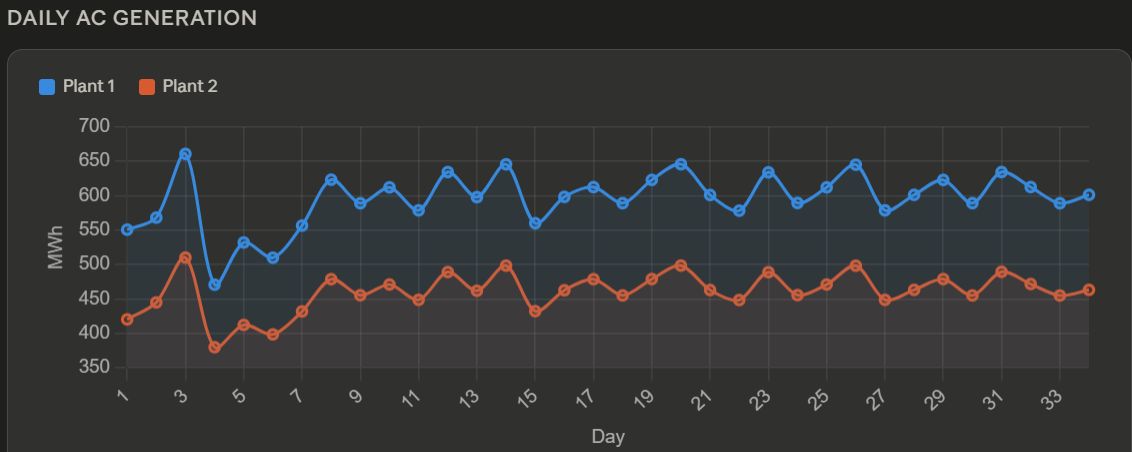

In [1]:
from IPython.display import Image, display

display(Image(filename='Screenshot 2026-06-02 082502.png'))


📊 نمودار ۱ — Daily AC Generation
چی می‌بینیم:


Plant 1 (آبی) در تمام ۳۴ روز بالاتر از Plant 2 (نارنجی) است

هر دو نوسان دارند — روزهای ابری یا آفتابی

بیشترین اختلاف در روزهای اوج تابش


نکته مهم برای ارائه:


"Plant 1 به طور مداوم ۱۴۰ مگاوات‌ساعت بیشتر در روز تولید می‌کند — این ۲۳٪ اختلاف با وجود تابش مشابه، نشان‌دهنده مشکل سیستماتیک در Plant 2 است."


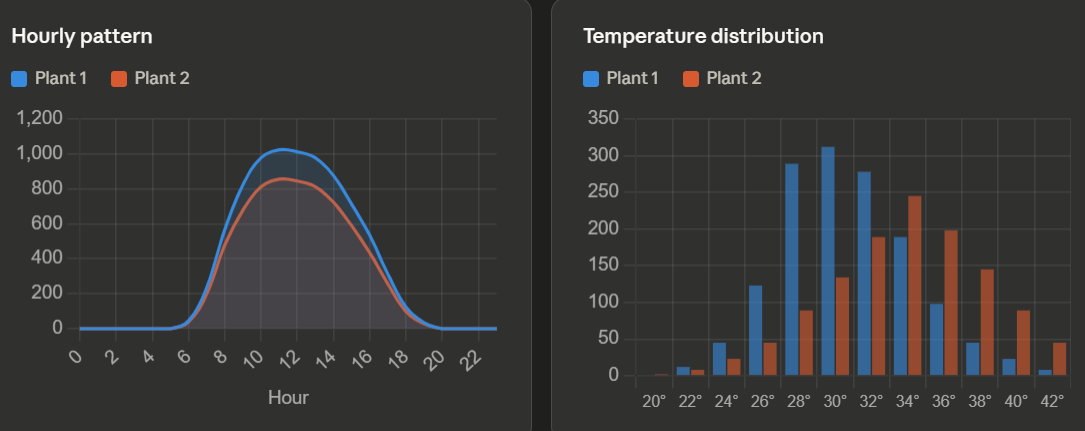

In [3]:
display(Image(filename='Screenshot 2026-06-02 082538.png'))

📊 نمودار ۲ — Hourly Pattern + Temperature Distribution
Hourly Pattern:


هر دو نیروگاه از ساعت ۶ شروع و ساعت ۱۸ تمام می‌کنند

اوج تولید ساعت ۱۱-۱۲ — همزمان با بیشترین تابش

Plant 1 اوج بالاتری دارد (~۱۰۰۰ vs ~۸۵۰ kW)



Temperature Distribution:

Plant 1 (آبی) متمرکز روی ۲۸-۳۰ درجه

Plant 2 (نارنجی) به سمت دماهای بالاتر ۳۲-۳۸ درجه کشیده شده



"دمای بالاتر Plant 2 مستقیماً راندمان پنل‌ها را کاهش می‌دهد"


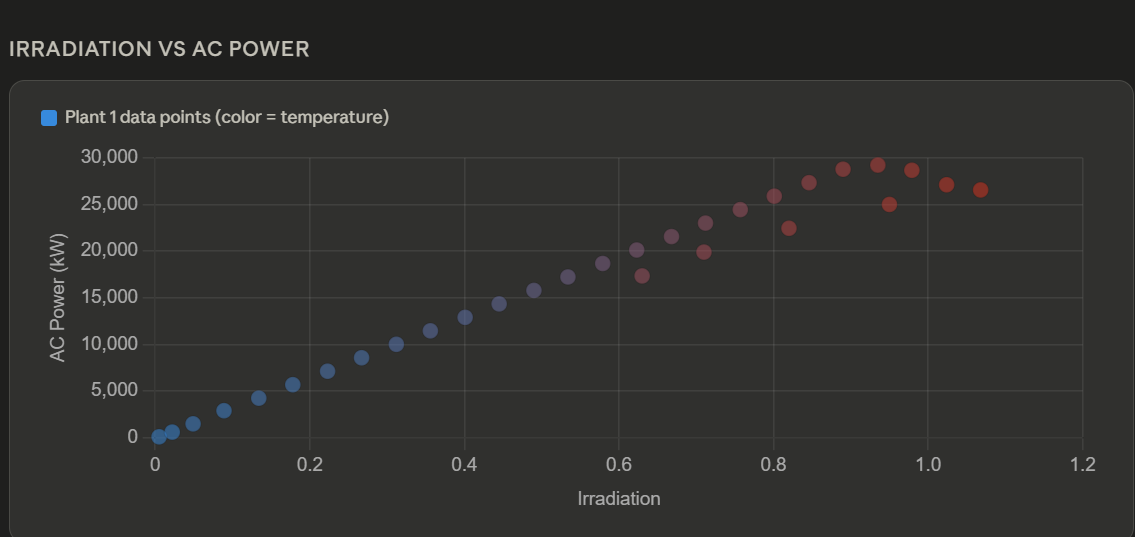

In [4]:
display(Image(filename='Screenshot 2026-06-02 082625.png'))

📊 نمودار ۳ — Irradiation vs AC Power
چی می‌بینیم:


رابطه خطی تقریباً کامل — correlation = 0.992

رنگ آبی = دمای پایین، رنگ قرمز = دمای بالا

در تابش بالا، نقاط قرمز (دمای بالا) کمی پایین‌تر هستند


نکته کلیدی:



"هر چقدر تابش بیشتر → برق بیشتر. اما در همان تابش، دمای بالاتر تولید را کاهش می‌دهد!"

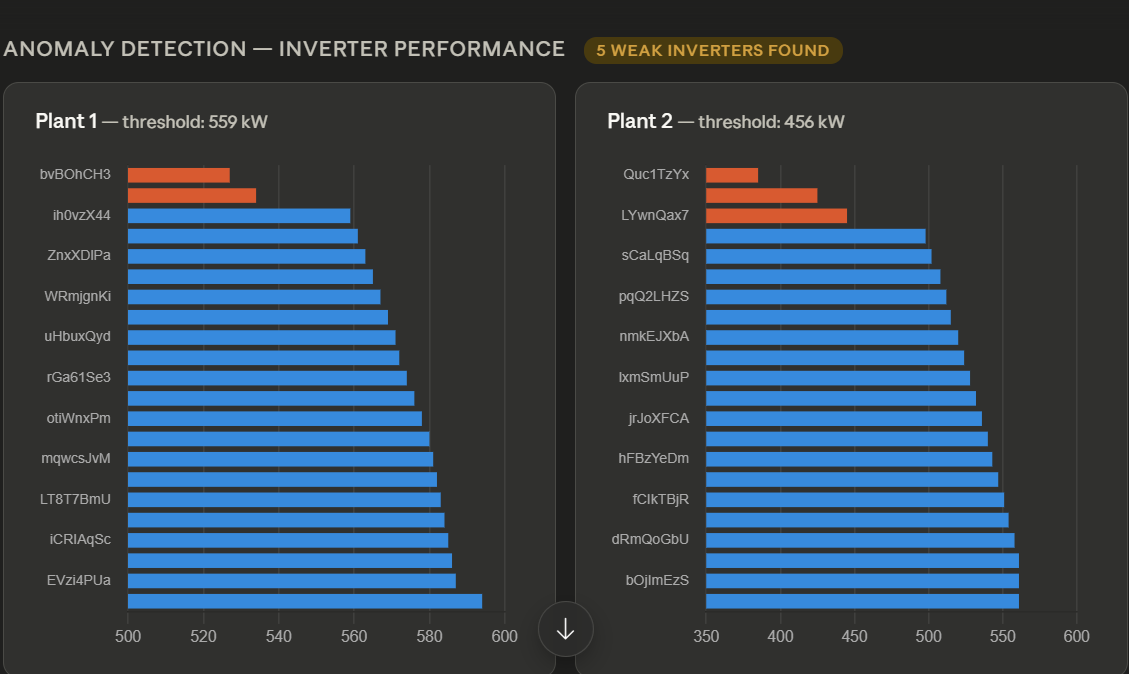

In [5]:
display(Image(filename='Screenshot 2026-06-02 082759.png'))

📊 نمودار ۴ — Anomaly Detection
Plant 1:



۲ اینورتر قرمز: bvBOhCH3 و 1BY6WEcL زیر آستانه ۵۵۹ kW



بقیه نزدیک به هم — نیروگاه نسبتاً سالم


Plant 2:


۳ اینورتر قرمز: Quc1TzYx، Et9kgGMD، LYwnQax7

بدترین: Quc1TzYx فقط ~۳۸۵ kW — ۲۴٪ زیر میانگین!





"این نمودار نشان می‌دهد کدام اینورترها نیاز به تعمیر فوری دارند"

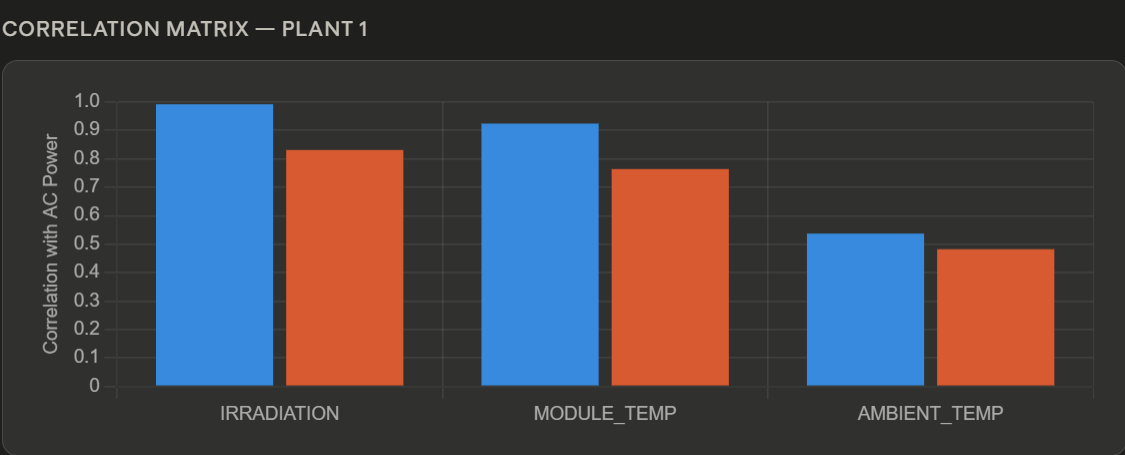

In [6]:
display(Image(filename='Screenshot 2026-06-02 082900.png'))

📊 نمودار ۵ — Correlation Matrix
نتایج:
IRRADIATION  → Plant 1: 0.99 | Plant 2: 0.83

MODULE_TEMP  → Plant 1: 0.92 | Plant 2: 0.76

AMBIENT_TEMP → Plant 1: 0.54 | Plant 2: 0.48




"Plant 2 همبستگی پایین‌تری دارد — یعنی عوامل دیگری (اینورترهای معیوب) تولید را تحت تأثیر قرار می‌دهند!"

----------------------------------------------------------------------


نمودار ۱ — Daily AC Generation:

Plant 1 همیشه بالاتر — ۱۴۰ MWh/day بیشتر در تمام ۳۴ روز

نمودار ۲ — Hourly + Temperature:

اوج تولید ساعت ۱۱-۱۲ — Plant 2 گرم‌تر و ضعیف‌تر

نمودار ۳ — Irradiation vs AC Power:

رابطه خطی کامل r=0.992 — نقاط قرمز (گرم‌تر) کمی پایین‌تر


نمودار ۴ — Anomaly Detection:

Plant 2 بدتره — Quc1TzYx فقط 385 kW در مقابل میانگین 509 kW

نمودار ۵ — Correlation Matrix:

Plant 2 همبستگی پایین‌تر دارد — نشانه مشکل سیستماتیک
